<a href="https://colab.research.google.com/github/hashirahmad806/-Doctor-Hub-Web/blob/main/Laptop_Price__Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [446]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [447]:
df = pd.read_csv('/content/laptop_data.csv')

df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [448]:
df.shape

(1303, 12)

In [449]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [450]:
# checking the  Duplicated   Rows

df.duplicated().sum()

np.int64(0)

In [451]:
 df.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [452]:
#  Droping the   column   name is   unnamed  which is meanings less
df.drop( columns=['Unnamed: 0'] ,inplace=True)

In [453]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [454]:
# Now  removed the GB  from the  Ram
df['Ram'] = df['Ram'].str.replace('GB','')
#Now  also  removed  kg  from the  Wieght

df['Weight'] = df['Weight'].str.replace('kg','')

In [455]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [456]:
# changing its data types  from String or object to the  int and float
df['Ram'] = df['Ram'].astype('int32')
df['Weight'] = df['Weight'].astype('float32')

In [457]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 101.9+ KB


Text(4.944444444444445, 0.5, 'Density')

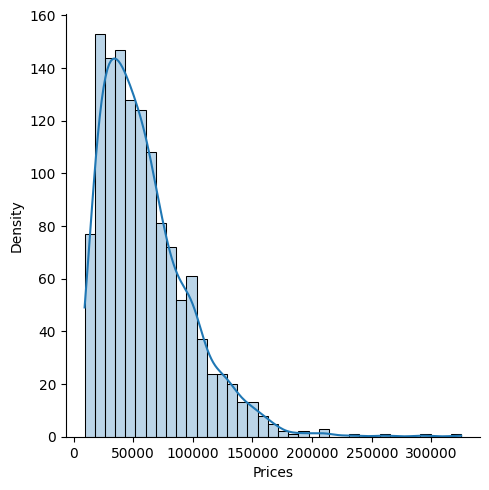

In [458]:
import matplotlib.ticker as mtick

# now  performing the  EDA

g = sns.displot(df['Price'] ,kde=True , alpha =0.3)
plt.xlabel('Prices')
plt.ylabel('Density')



In [459]:
df['Company'].value_counts()

,count
Company,
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


<Axes: xlabel='Company'>

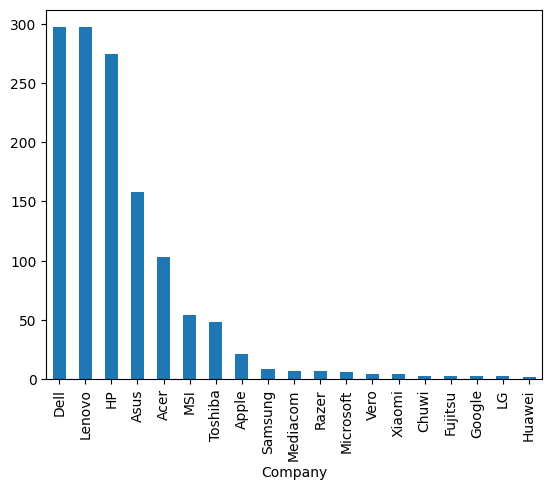

In [460]:
df['Company'].value_counts().plot(kind='bar')

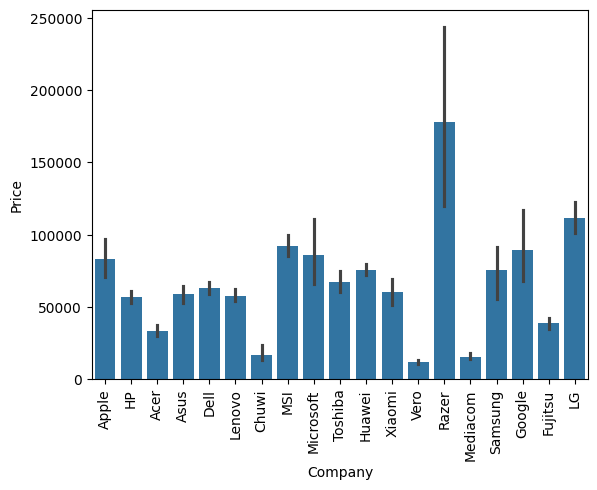

In [461]:
#  Now  checking the price of each company  laptops    base on the price
sns.barplot(data=df , x='Company' , y='Price')
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

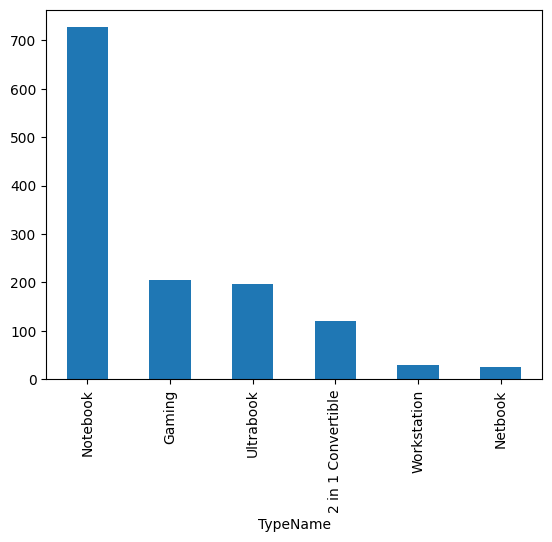

In [462]:
#  now checking how   much  type of Laptops  We Have

df['TypeName'].value_counts().plot(kind='bar')

# this means  that we  have   6 types of laptops


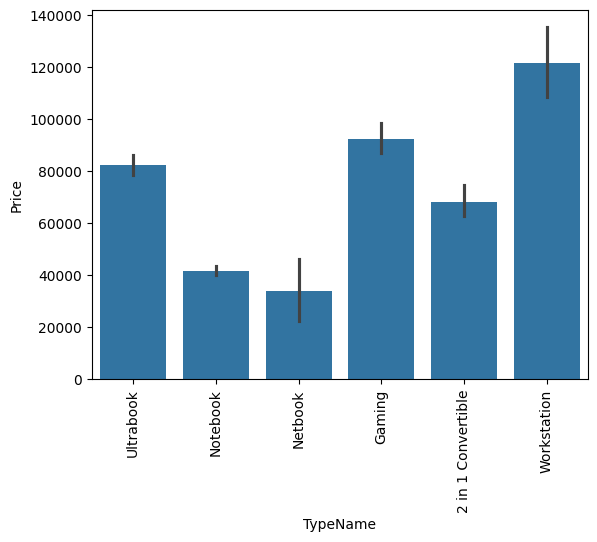

In [463]:
#  Now  checking the  Avarage  values of type of laptops  solods
sns.barplot(data=df , x='TypeName' , y='Price')
plt.xticks(rotation='vertical')
plt.show()

#  this means that   high price  have the works-Stations and then Gaming and then ultrabook and so on

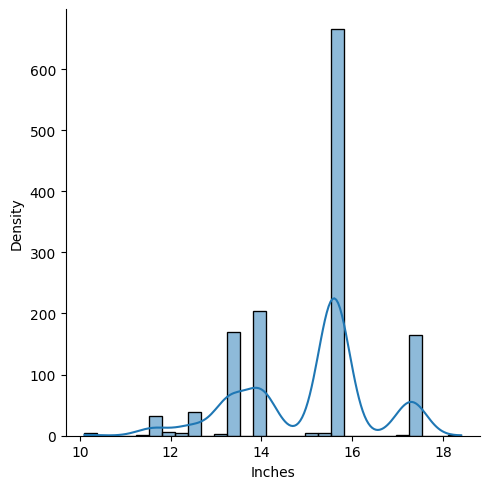

In [464]:
#   the   price  on the  size of laptop

sns.displot(df['Inches']  ,kde=True)
plt.ylabel('Density')
plt.xlabel('Inches')
plt.show()


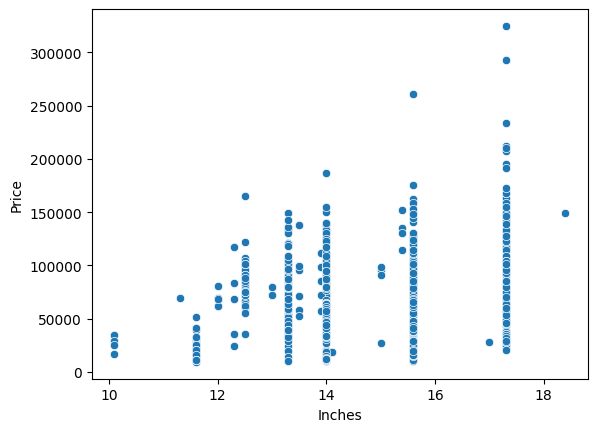

In [465]:
# now lets see in the scater  plot on the

sns.scatterplot(data=df , x='Inches' , y='Price')
plt.show()
#  this  graph is showed that the  the sized  increase  price also increase


In [466]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [467]:
# now  lets  do  some  feature Engineering
# creating new  columns  showing that     every leptops  is  touch screen or not


df['TouchScreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0


In [468]:
#  checking the sampple  means rendomly select data
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
219,Dell,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Intel UHD Graphics 620,Windows 10,1.62,68145.12,1
1200,Dell,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4,128GB SSD,AMD Radeon R7 M440,Windows 10,2.30,26586.72,0
608,Lenovo,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256GB SSD,Intel HD Graphics 630,Windows 10,2.00,69210.72,1
222,Toshiba,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.20,72620.64,0
785,MSI,Gaming,14.0,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,1.60,100752.48,0


<Axes: xlabel='TouchScreen'>

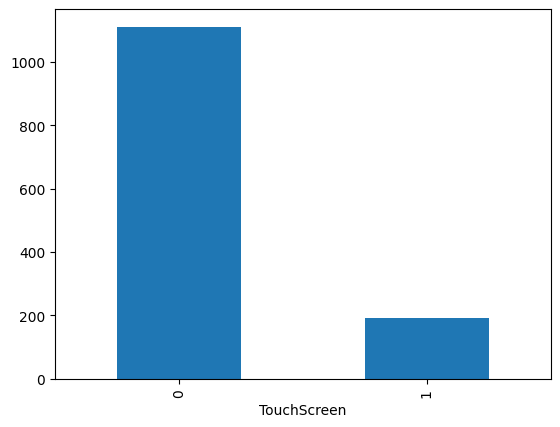

In [469]:
#  Now checking how laptops  have Touch Screen  or  not  Touch  screen

df['TouchScreen'].value_counts().plot(kind='bar')
#

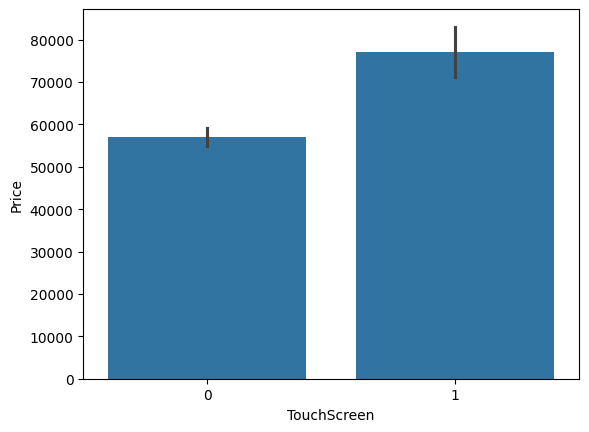

In [470]:
#  now   lets see that   the price   of the  screens  relations
sns.barplot(data=df , x='TouchScreen' , y='Price')
plt.show()

In [471]:

# creating new  columns  showing that     every leptops  is  IPS   or not


df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS ' in x else 0)
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0


<Axes: xlabel='IPS'>

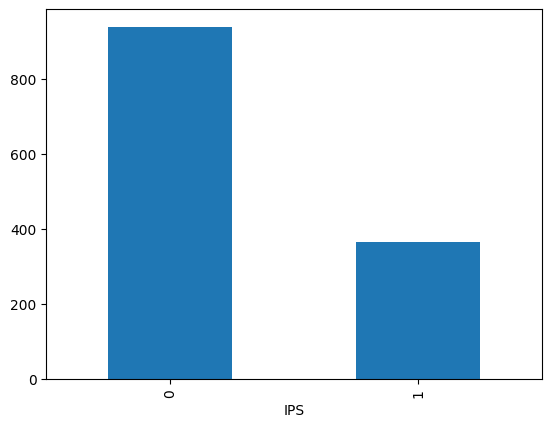

In [472]:
#  Now checking how laptops  have Touch Screen  or  not  Touch  screen

df['IPS'].value_counts().plot(kind='bar')
#

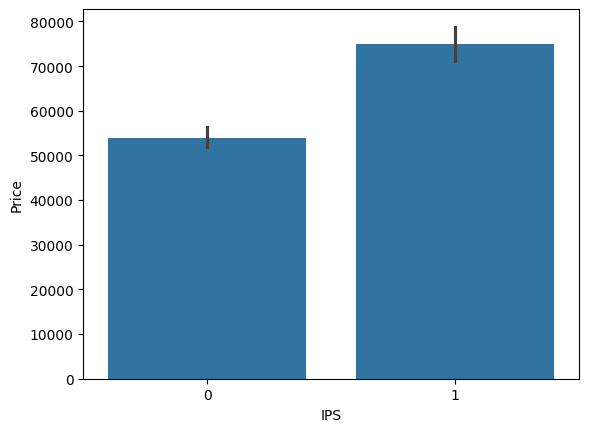

In [473]:
 # Now  lets  the  Price  of   the ips  laptos

 #  now   lets see that   the price   of the  screens  relations
sns.barplot(data=df , x='IPS' , y='Price')
plt.show()

In [474]:
new = df['ScreenResolution'].str.split('x' ,n=1,expand=True)
new

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [475]:
df['X_res'] = new[0]
df['Y_res'] = new[1]
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,IPS Panel Retina Display 2560,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,IPS Panel Full HD / Touchscreen 1920,1080
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,1366,768
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,1366,768


In [476]:
# here is the problems   in the   x resolution in  have  string      so  Adding some  regular  expresssion

df['X_res'].str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

,X_res
0,2560
1,1440
2,1920
3,2880
4,2560
...,...
1298,1920
1299,3200
1300,1366
1301,1366


In [477]:
# First, extract only the numeric part from 'X_res' using regex and assign it back
df['X_res'] = df['X_res'].str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

# Now, change its data type to int
df['X_res'] = df['X_res'].astype('int')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   int64  
 14  Y_res             1303 non-null   object 
dtypes: float32(1), float64(2), int32(1), int64(3), object(8)
memory usage: 142.6+ KB


In [478]:
# Also  for the  y resolution   changing the data type
df['Y_res']=df['Y_res'].astype('int')

In [479]:
# now  find  relation  of each colunm  withe  price

# Select only numeric columns for correlation calculation
df.select_dtypes(include=['number']).corr()['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
X_res,0.556529
Y_res,0.552809
IPS,0.252208
Weight,0.210370
TouchScreen,0.191226
Inches,0.068197


## PPI ###
# **primarily** refers to ```Pixels Per Inch ```(screen resolution/image quality) or the Producer Price Index (economic inflation measure). PPI measures pixel density (higher means sharper images), while the economic PPI tracks average changes in domestic producer selling prices.


 Other uses include Proton Pump Inhibitors (medical) and Private Personal Information.Usage Examples & SynonymsPixels Per Inch (PPI):Usage: A screen with 300 PPI provides sharp text, *while* 72 PPI is common for standard digital images. Digital cameras and Photoshop settings use this to define image resolution.Synonyms/Related Terms: Pixel density, resolution, screen resolution, image density.Producer Price Index (PPI):Usage: Economists use the PPI released by the Bureau of Labor Statistics (BLS) to analyze monthly wholesale inflation trends.Synonyms/Related Terms: Wholesale price index (former name), factory-gate inflation, producer price inflatio


  formula  for it
   Pixels Per Inch (Technology)This formula determines the pixel density of a screen. To find it, you first calculate the diagonal resolution in pixels using the Pythagorean theorem, then divide by the
    physical diagonal size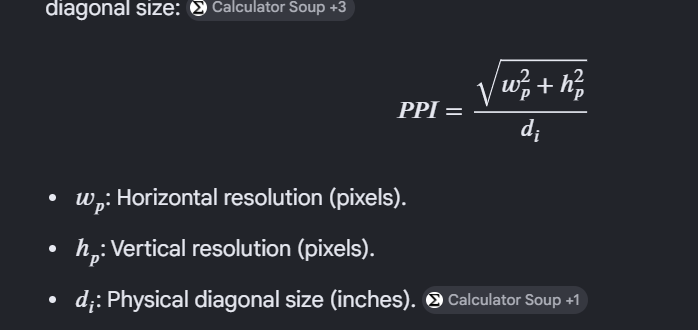

In [480]:
df['PPI']=((np.square(df['X_res'])+np.square(df['Y_res']))**0.5 /df['Inches']).astype('float')

df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,1920,1080,157.350512
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,3200,1800,276.053530
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,1366,768,111.935204
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,1366,768,100.454670


In [481]:
df.select_dtypes(include=['number']).corr()['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
X_res,0.556529
Y_res,0.552809
PPI,0.473487
IPS,0.252208
Weight,0.210370
TouchScreen,0.191226
Inches,0.068197


In [482]:
 # Now  droping the Screen resoultion  We Extracte  All Ouer   Required   elements
  # so now droping its
df.drop(columns=['ScreenResolution'],inplace=True)
df

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,1920,1080,157.350512
1299,Lenovo,2 in 1 Convertible,13.3,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,3200,1800,276.053530
1300,Lenovo,Notebook,14.0,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,1366,768,111.935204
1301,HP,Notebook,15.6,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,1366,768,100.454670


In [483]:
# Now  removing the columns which  is  not   required  means  that  it   have  now  effect on the price

df.drop(columns=['Inches' ,'X_res' ,'Y_res']  ,inplace=True )


In [484]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   object 
 1   TypeName     1303 non-null   object 
 2   Cpu          1303 non-null   object 
 3   Ram          1303 non-null   int32  
 4   Memory       1303 non-null   object 
 5   Gpu          1303 non-null   object 
 6   OpSys        1303 non-null   object 
 7   Weight       1303 non-null   float32
 8   Price        1303 non-null   float64
 9   TouchScreen  1303 non-null   int64  
 10  IPS          1303 non-null   int64  
 11  PPI          1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), int64(2), object(6)
memory usage: 112.1+ KB


,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


In [485]:
#  now seeing the  Cpu   columns   here also have  differents  types of  kinds of processor   we need  to make  seperate them like screen Resolutions

df['Cpu'].value_counts()


#



,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core i5 7200U 2.70GHz,1
Intel Core M M7-6Y75 1.2GHz,1
Intel Core M 6Y54 1.1GHz,1


In [486]:
df['Cpu Name'] =df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [487]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [488]:
def fetch_processor(text) :
  if text == 'Intel Core i7' or text =='Intel Core i5' or text == 'Intel Core i3':
   return text
  else :
        if text.split()[0] == 'Intel' :
          return 'Other intel Processor'
        else :
         return 'AMD Processor'

In [489]:
df['Cpu Brand'] = df['Cpu Name'].apply(fetch_processor)

df['Cpu Brand'].sample(10)

,Cpu Brand
698,Intel Core i7
1164,Intel Core i5
1149,Intel Core i7
92,Intel Core i7
308,Intel Core i5
148,Intel Core i7
221,Intel Core i5
316,Intel Core i7
1300,Other intel Processor
1013,Intel Core i7


<Axes: xlabel='Cpu Brand'>

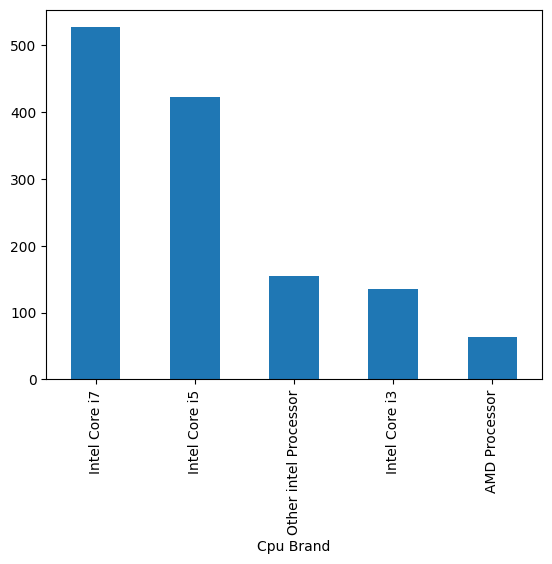

In [490]:
df['Cpu Brand'].value_counts().plot(kind='bar')

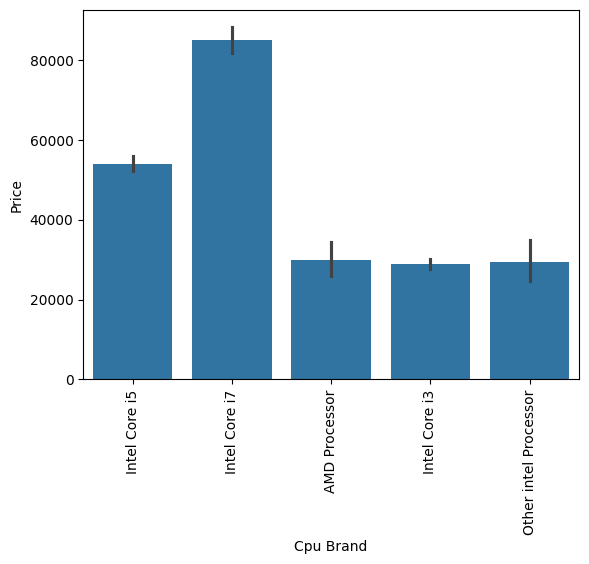

In [491]:
sns.barplot(data=df , x='Cpu Brand' , y='Price')
plt.xticks(rotation='vertical')
plt.show()
#   this means that the intel core 7 starts on the avrage  80k  to  83k   i5 start  arround 50k  this means  that  prices  of lapots  aslo  depands on the   Cors



In [492]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,Cpu Name,Cpu Brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


In [493]:
#  now  remove the  Cpu  and Cpu name
df.drop(columns=['Cpu' ,'Cpu Name'] , inplace=True)

df

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,Cpu Brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7
1299,Lenovo,2 in 1 Convertible,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7
1300,Lenovo,Notebook,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Other intel Processor
1301,HP,Notebook,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7


<Axes: xlabel='Ram'>

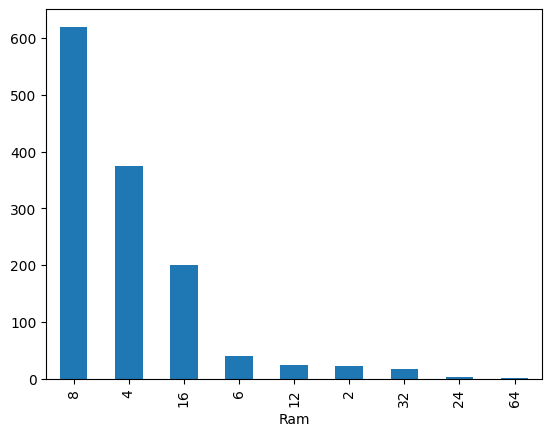

In [494]:
# [162]
#   now  prices  Relations  with the   Ram
df['Ram'].value_counts() #    kind of Rams   we have
df['Ram'].value_counts().plot(kind='bar')

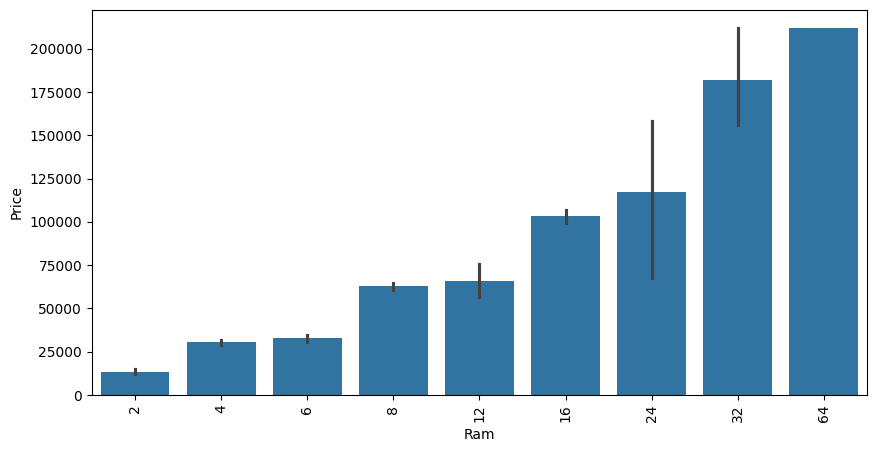

In [495]:
plt.figure(figsize=(10,5))

sns.barplot(data=df , x='Ram' , y='Price')
plt.xticks(rotation='vertical')
plt.show()
#   the  means that   Ram    clearly involove in the Price



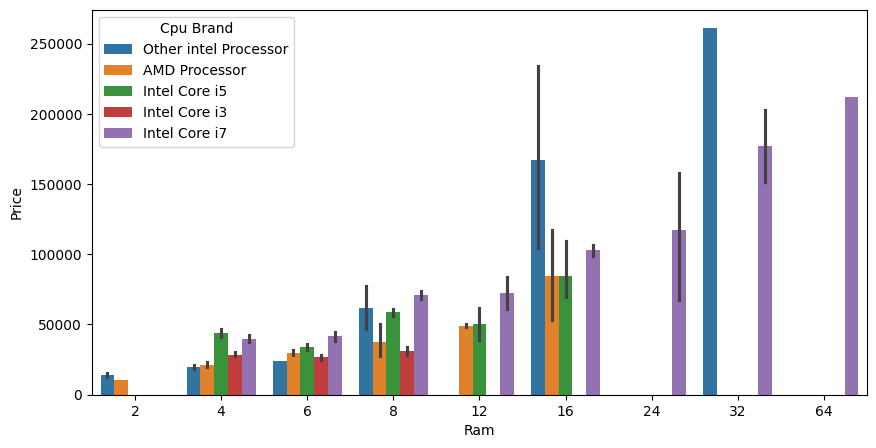

In [496]:
plt.figure(figsize=(10,5))

sns.barplot(data=df , x='Ram' , y='Price' , hue='Cpu Brand')
plt.xticks(rotation='horizontal')
plt.show()

In [497]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [498]:
# Cleaning the Memory column
df['Memory'] = df['Memory'].astype(str).str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')

# Splitting Memory into types
new_memory = df['Memory'].str.split('+', expand=True)

# Function to extract storage amount and type
def get_storage_info(memory_str):
    if pd.isna(memory_str): return 0, ''
    memory_str = memory_str.strip()
    if 'SSD' in memory_str: return int(re.findall(r'(\d+)', memory_str)[0]), 'SSD'
    if 'HDD' in memory_str: return int(re.findall(r'(\d+)', memory_str)[0]), 'HDD'
    if 'Flash Storage' in memory_str: return int(re.findall(r'(\d+)', memory_str)[0]), 'Flash Storage'
    if 'Hybrid' in memory_str: return int(re.findall(r'(\d+)', memory_str)[0]), 'Hybrid'
    return 0, ''

# Applying the function to extract primary memory
import re
df['first'] = new_memory[0].apply(lambda x: get_storage_info(x)[0])
df['first_type'] = new_memory[0].apply(lambda x: get_storage_info(x)[1])

# Initialize columns for secondary memory
df['second'] = 0
df['second_type'] = ''

# Process secondary memory if it exists
if 1 in new_memory.columns:
    df.loc[new_memory[1].notna(), 'second'] = new_memory[1].dropna().apply(lambda x: get_storage_info(x)[0])
    df.loc[new_memory[1].notna(), 'second_type'] = new_memory[1].dropna().apply(lambda x: get_storage_info(x)[1])

# Aggregate storage into SSD and HDD columns
df['SSD'] = df.apply(lambda x: x['first'] if x['first_type'] == 'SSD' else 0, axis=1)
df['HDD'] = df.apply(lambda x: x['first'] if x['first_type'] == 'HDD' else 0, axis=1)
df['Flash_Storage'] = df.apply(lambda x: x['first'] if x['first_type'] == 'Flash Storage' else 0, axis=1)
df['Hybrid'] = df.apply(lambda x: x['first'] if x['first_type'] == 'Hybrid' else 0, axis=1)

df['SSD'] = df.apply(lambda x: x['SSD'] + x['second'] if x['second_type'] == 'SSD' else x['SSD'], axis=1)
df['HDD'] = df.apply(lambda x: x['HDD'] + x['second'] if x['second_type'] == 'HDD' else x['HDD'], axis=1)
df['Flash_Storage'] = df.apply(lambda x: x['Flash_Storage'] + x['second'] if x['second_type'] == 'Flash Storage' else x['Flash_Storage'], axis=1)
df['Hybrid'] = df.apply(lambda x: x['Hybrid'] + x['second'] if x['second_type'] == 'Hybrid' else x['Hybrid'], axis=1)

# Drop intermediate and original Memory columns
df.drop(columns=['Memory', 'first', 'first_type', 'second', 'second_type'], inplace=True)



In [499]:
df.sample(15)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,Cpu Brand,SSD,HDD,Flash_Storage,Hybrid
911,HP,Ultrabook,8,Intel HD Graphics 515,Windows 10,1.09,165168.0000,1,0,352.465147,Other intel Processor,240,0,0,0
787,Lenovo,Gaming,4,Nvidia GeForce GTX 1050,Windows 10,2.40,53226.7200,0,1,141.211998,Intel Core i7,0,1000,0,0
368,Dell,Notebook,8,AMD Radeon R7 M445,Windows 10,2.33,47898.7200,0,0,141.211998,Intel Core i7,256,0,0,0
166,Acer,Notebook,4,Intel HD Graphics 505,Windows 10,2.10,19367.8128,0,0,100.454670,Other intel Processor,0,1000,0,0
942,Acer,Notebook,4,Intel HD Graphics 620,Windows 10,2.23,32980.3200,0,0,100.454670,Intel Core i5,0,500,0,0
224,Dell,Gaming,16,Nvidia GeForce GTX 1060,Windows 10,4.42,130873.7952,0,1,127.335675,Intel Core i7,256,1000,0,0
767,Dell,Gaming,16,Nvidia GeForce GTX 960M,Windows 10,2.72,58554.7200,1,1,282.423996,Intel Core i7,128,1000,0,0
542,HP,Ultrabook,8,Intel HD Graphics 620,Windows 10,1.34,61005.6000,0,1,276.053530,Intel Core i7,256,0,0,0
391,Asus,Gaming,16,Nvidia GeForce GTX 1050 Ti,Windows 10,3.00,84768.4800,0,0,127.335675,Intel Core i7,256,1000,0,0
769,Acer,Notebook,4,Intel HD Graphics 505,Linux,2.10,15877.4400,0,0,100.454670,Other intel Processor,0,1000,0,0


In [501]:
# Now checking the correlations

# Select only numeric columns for correlation calculation
df.select_dtypes(include=['number']).corr()['Price']

,Price
Ram,0.743007
Weight,0.210370
Price,1.000000
TouchScreen,0.191226
IPS,0.252208
PPI,0.473487
SSD,0.670799
HDD,-0.095476
Flash_Storage,-0.040511
Hybrid,-0.004769


In [ ]:
#   Fron